# Mall Customer Segmentation

**Goal:** group mall customers into meaningful segments based on age, income, and spending behavior — the kind of analysis a marketing team would use to target different customer groups with different campaigns, instead of treating every customer the same.

**Dataset:** [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) (Kaggle) — 200 mall customers with age, gender, annual income, and a spending score (1–100, assigned by the mall based on customer behavior).

**Approach:** exploratory analysis → K-Means clustering (with the elbow method to choose the number of clusters) → hierarchical clustering as a cross-check → cluster profiling (what does each segment actually look like?) → training a classifier on the resulting cluster labels, so that a *new* customer can be assigned to a segment instantly without re-running clustering on the entire dataset.


In [1]:
import pandas as pd

data = pd.read_csv('Mall_Customers.csv')

print(data.head())

print(data.info())

print(data.describe())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)

**Observation:** 200 customers, no missing values — small and clean, typical of a tutorial-scale dataset. The three numeric fields (Age, Annual Income, Spending Score) are what drive the segmentation.


## 1. Exploratory analysis

Before clustering anything, it's worth seeing the shape of each variable individually and how they relate pairwise — this gives a sense of whether natural groupings are even visible before the algorithm looks for them.


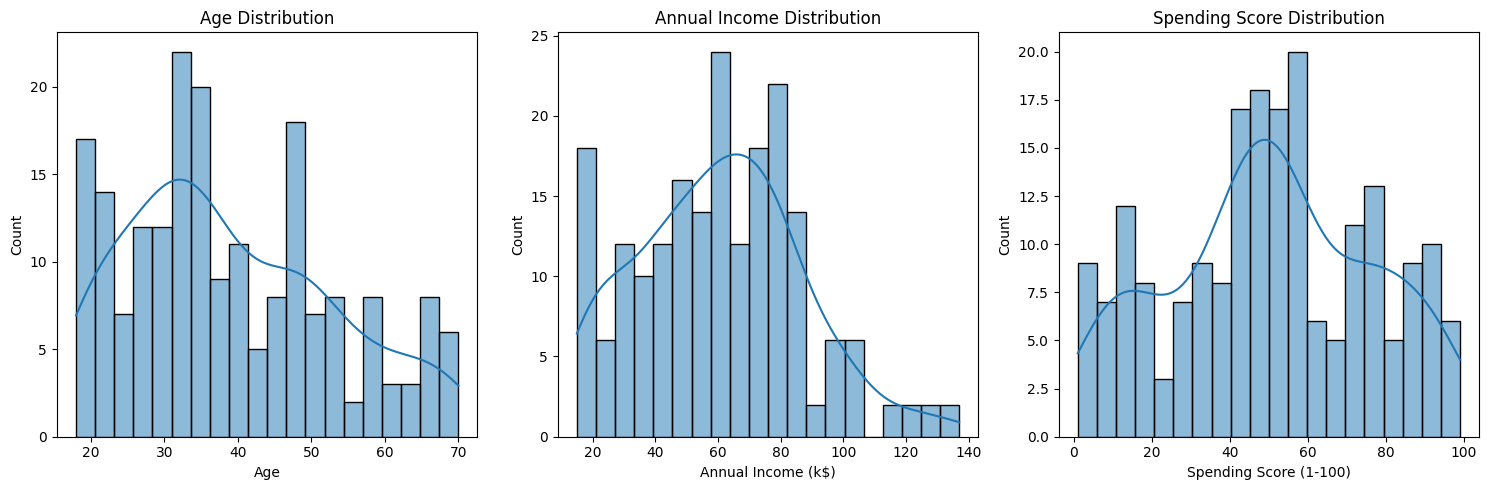

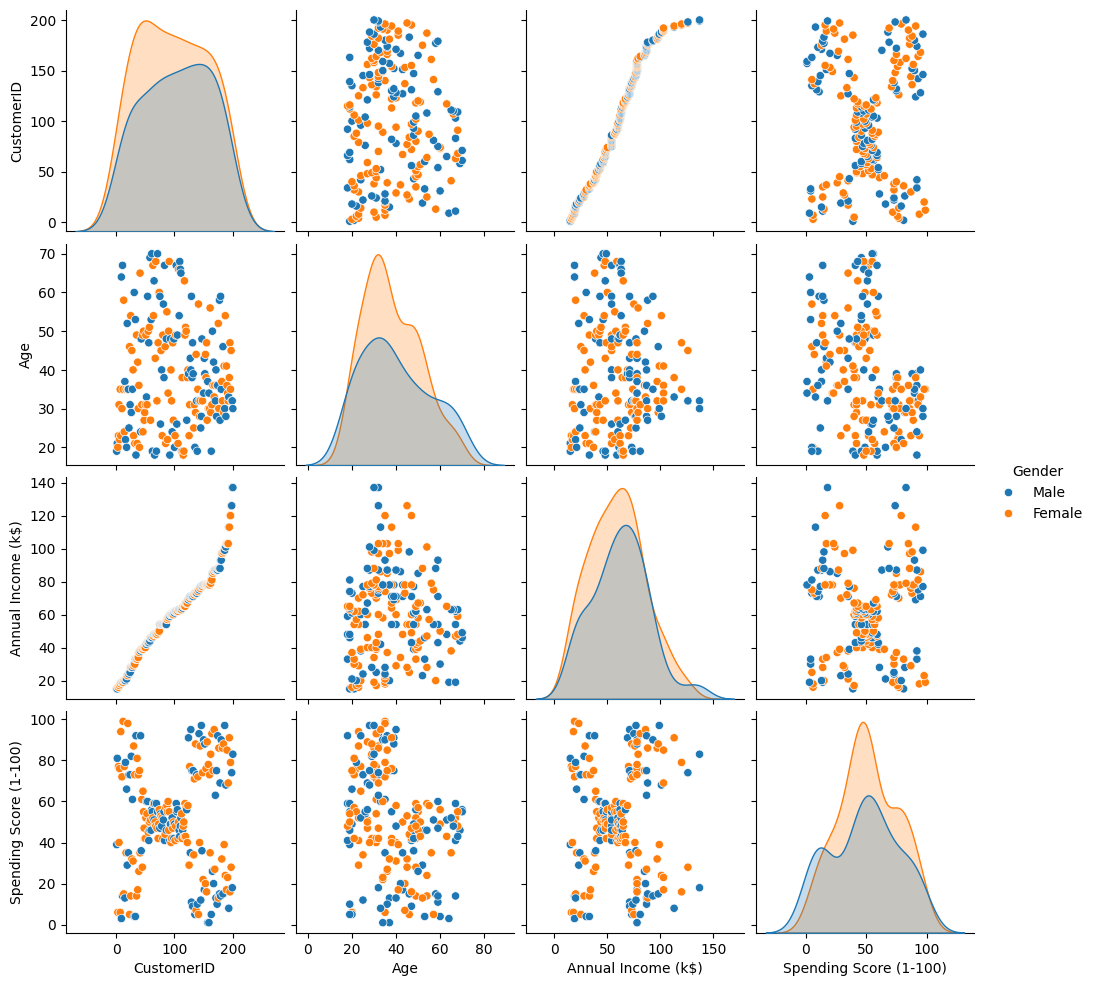

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data['Annual Income (k$)'], bins=20, kde=True)
plt.title('Annual Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

sns.pairplot(data, hue='Gender')
plt.show()


**Observation:** annual income and spending score don't correlate in an obvious straight line — which is exactly why clustering is useful here. A simple rule like "high income = high spender" clearly doesn't hold for all customers; there are customers with high income but low spending, and vice versa. That's the pattern K-Means is about to formalize into distinct groups.


## 2. Preprocessing

Gender is label-encoded (0/1) so it can be used numerically, and all features are standardized (`StandardScaler`) before clustering — this matters because K-Means uses Euclidean distance, and without scaling, `Annual Income` (values in the thousands) would completely dominate the distance calculation over `Spending Score` (values 1–100).


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

X = data[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Choosing the number of clusters — the elbow method

K-Means requires picking the number of clusters in advance. The elbow method plots within-cluster variance (WCSS) against different values of *k* — the "elbow" point, where adding more clusters stops meaningfully reducing variance, is a reasonable choice. Here that point is around **k=5**, which is also what the well-known analysis of this dataset converges to (five intuitive segments: e.g. high income/low spenders, low income/high spenders, and so on).


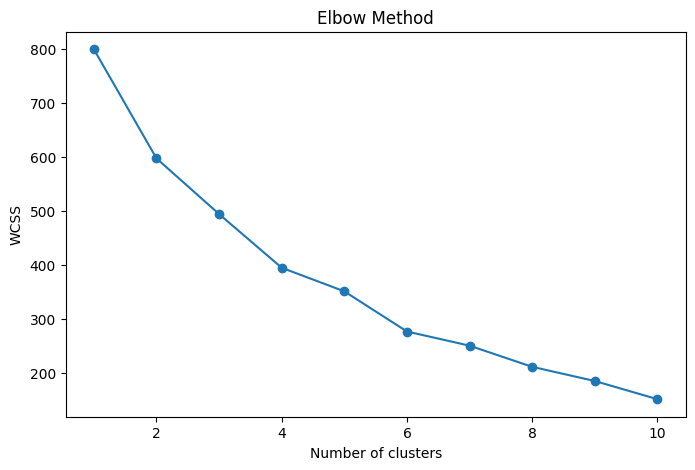

In [4]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters


## 4. Hierarchical clustering — a cross-check

K-Means requires choosing *k* upfront and assumes roughly spherical clusters. Hierarchical (agglomerative) clustering doesn't need *k* specified beforehand — the dendrogram itself shows how clusters merge at different distance thresholds, which is a useful independent check on whether 5 clusters is actually a reasonable structural choice, not just an artifact of the elbow method.


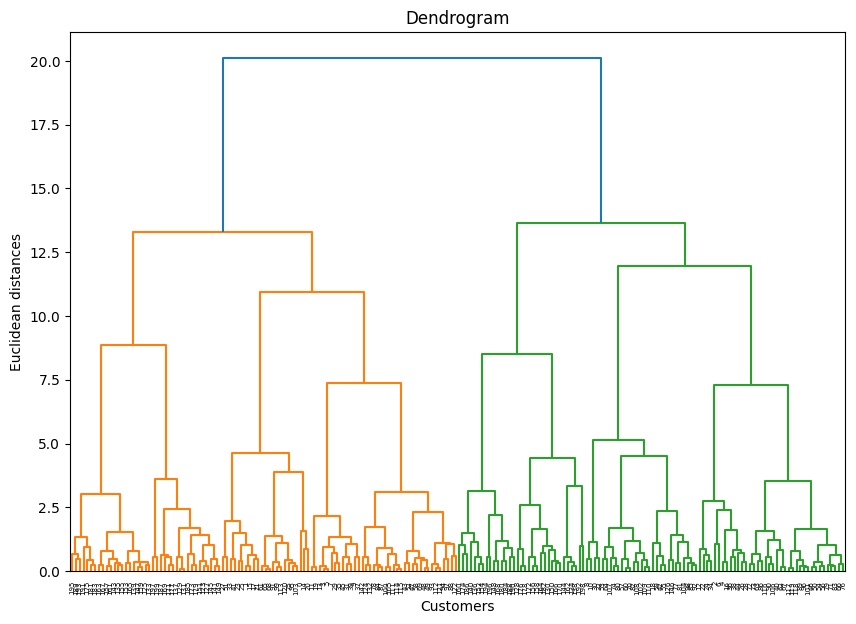

In [5]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
data['HCluster'] = hc.fit_predict(X_scaled)


**Observation:** the dendrogram's largest vertical gaps are consistent with a 5-cluster cut, which agrees with the K-Means elbow result — two different clustering methods converging on the same structure is a stronger signal than either one alone.


## 5. Profiling the clusters — what does each segment actually look like?

Cluster *numbers* mean nothing to a marketing team on their own — what matters is translating each cluster into a plain-language customer profile (e.g. "young, high income, high spenders" vs. "older, moderate income, low spenders") so the segments are actually actionable.


         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         65.333333  0.509804  56.470588           46.098039   
1        159.500000  1.000000  39.500000           85.150000   
2        100.809524  1.000000  28.690476           60.904762   
3        151.510204  0.000000  37.897959           82.122449   
4         50.526316  0.000000  27.315789           38.842105   

         Spending Score (1-100)  HCluster  
Cluster                                    
0                     39.313725  3.411765  
1                     14.050000  2.200000  
2                     70.238095  0.619048  
3                     54.448980  1.428571  
4                     56.210526  0.552632  


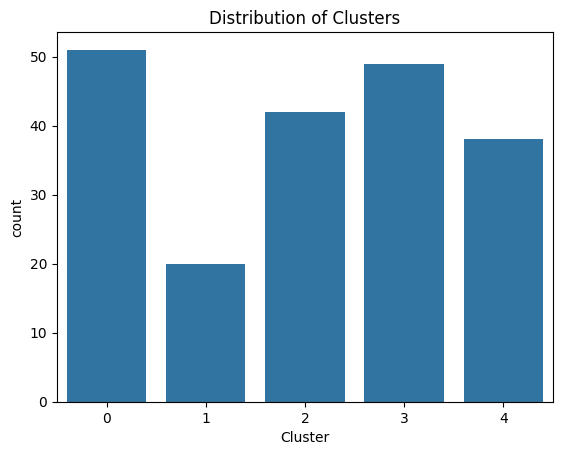

In [6]:
cluster_profile = data.groupby('Cluster').mean()
print(cluster_profile)

sns.countplot(x='Cluster', data=data)
plt.title('Distribution of Clusters')
plt.show()


## 6. Age groups — an additional demographic lens

Beyond the clustering itself, bucketing customers into age groups gives a second, simpler dimension that's often more directly usable in a real marketing campaign than a cluster ID.


In [7]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['Teen', 'Young Adult', 'Adult', 'Senior', 'Elder'])


## 7. From clusters to a reusable classifier

K-Means only tells you the segments for the customers *currently in the dataset*. In practice, new customers show up constantly, and re-running clustering on the entire dataset every time isn't practical. So the cluster assignments are treated as labels, and a classifier (SVM and Decision Tree, compared here) is trained to predict a customer's segment from their raw features — meaning a brand-new customer can be assigned to a segment instantly, without touching the clustering algorithm again.


SVM Model Accuracy: 0.925
Decision Tree Model Accuracy: 0.9
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.83      0.91         6
           2       1.00      1.00      1.00         7
           3       1.00      0.82      0.90        11
           4       0.80      1.00      0.89         8

    accuracy                           0.93        40
   macro avg       0.94      0.93      0.93        40
weighted avg       0.94      0.93      0.92        40

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       1.00      1.00      1.00         6
           2       0.88      1.00      0.93         7
           3       0.91      0.91      0.91        11
           4       0.88      0.88      0.88         8

    accuracy                           0.90        40
   ma

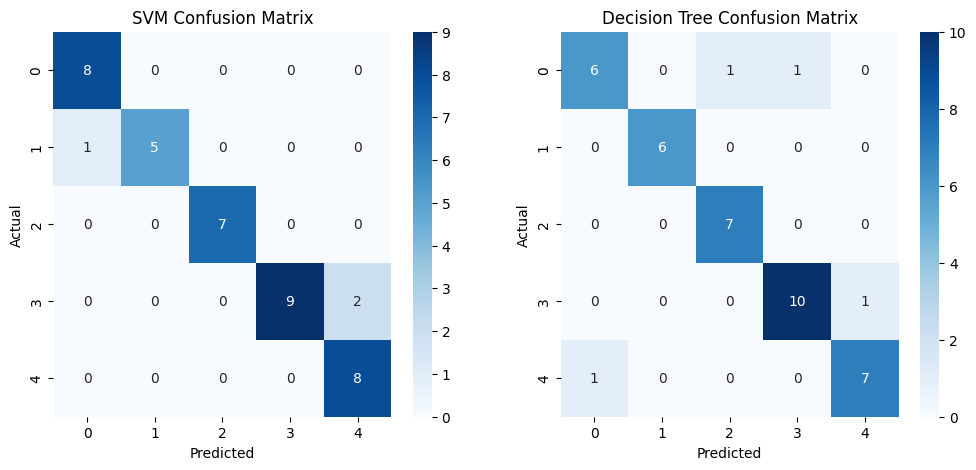

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, clusters, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("SVM Model Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Decision Tree Model Accuracy:", accuracy_score(y_test, y_pred_tree))

print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_tree))

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('SVM Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(conf_matrix_tree, annot=True, fmt='d', ax=ax[1], cmap='Blues')
ax[1].set_title('Decision Tree Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.show()


**Result:** SVM reaches 92.5% accuracy, Decision Tree 90% — both strong, which makes sense since the clusters K-Means found do correspond to genuinely separable regions in feature space (if they didn't, no classifier could reliably reproduce them). This closes the loop from "explore data → find segments → make segments usable for new customers."

## Summary

| Step | Result |
|---|---|
| Optimal clusters (elbow method) | k = 5 |
| Cross-check (hierarchical) | Confirms 5-cluster structure |
| Segment → classifier (SVM) | 92.5% accuracy |
| Segment → classifier (Decision Tree) | 90.0% accuracy |

**What I'd improve with more time:** validate cluster stability with a metric like silhouette score, try DBSCAN as a third clustering approach (it doesn't assume spherical clusters, unlike K-Means), and test the trained classifier on genuinely new/synthetic customer profiles rather than only a held-out split of the same dataset.
